In [114]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Loading DataSet
df= pd.read_csv("Movies.csv", engine='python')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [67]:
# Drop Irrelevant Coumns
df.drop(['Overview'], axis=1, inplace=True)
df.drop(['Poster_Url'], axis=1, inplace=True)
df.drop(['Original_Language'], axis=1, inplace=True)

In [68]:
# Understand the Data
print(df.shape)
print(df.columns)
df.describe()
df.info()
df.head()

(9837, 6)
Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9837 non-null   object 
 1   Title         9828 non-null   object 
 2   Popularity    9827 non-null   float64
 3   Vote_Count    9827 non-null   object 
 4   Vote_Average  9827 non-null   object 
 5   Genre         9826 non-null   object 
dtypes: float64(1), object(5)
memory usage: 461.2+ KB


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [69]:
# Checking the null values
(df.isnull().sum() / len(df)) *100

,0
Release_Date,0.000000
Title,0.091491
Popularity,0.101657
Vote_Count,0.101657
Vote_Average,0.101657
Genre,0.111823


In [76]:
# Fill the Null values for Numeric Columns
df["Popularity"]=df["Popularity"].fillna(df["Popularity"].median())

df["Vote_Count"]= pd.to_numeric(df["Vote_Count"] , errors='coerce')
df["Vote_Count"]= df["Vote_Count"].fillna(df["Vote_Count"].mean())

df["Vote_Average"]= pd.to_numeric(df["Vote_Average"] , errors='coerce')
df["Vote_Average"]= df["Vote_Average"].fillna(df["Vote_Average"].median())

In [75]:
# Fill the null values for Text columns
df['Title']= df['Title'].fillna("No Title")
df['Genre']= df['Genre'].fillna("Unknown")

In [71]:
# Check the Duplicated values
df.duplicated().sum()

np.int64(0)

In [77]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9837.000000,9837.000000,9837.000000
mean,40.301123,1392.943721,6.439534
std,108.820657,2609.843284,1.129167
min,7.100000,0.000000,0.000000
25%,16.130000,146.000000,5.900000
50%,21.191000,445.000000,6.500000
75%,35.160000,1382.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [78]:
#  Convert the Data type from Date_Time to String for Data Preprocessing
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [79]:
# Convert the Column Release Date From String to float
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].head()


,Release_Date
0,2021.0
1,2022.0
2,2022.0
3,2021.0
4,2021.0


In [80]:
# Convert Columns (Release Date and Vote Count) from Float to Integer
df['Release_Date'] = df['Release_Date'].fillna(0).astype(int)
df['Vote_Count'] = df['Vote_Count'].fillna(0).astype(int)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [81]:
# I Convert the Column( Vote_Average) from Float to Labels for Better Preprocessing
def categorize_column(df, col, labels):

  edge = [df[col].describe()['min'],
          df[col].describe()['25%'],
          df[col].describe()['50%'],
          df[col].describe()['75%'],
          df[col].describe()['max']]
#  Drop the Duplicates Labels
  df[col] = pd.cut(df[col], edge, labels=labels, duplicates='drop')
  return df

In [82]:
# Now Categorize all Lables in 4 terms:
labels= ['Not_Popular', 'Average', 'Popular', 'Very_Popular']
df= categorize_column(df, 'Vote_Average', labels)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Very_Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Average,Thriller
3,2021,Encanto,2402.201,5076,Very_Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Popular,"Action, Adventure, Thriller, War"


In [83]:
# Count the Vote_Average That how much labels are included in data
df['Vote_Average'].value_counts()

,count
Vote_Average,
Not_Popular,2467
Very_Popular,2450
Popular,2411
Average,2409


In [84]:
df.dropna(inplace= True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [85]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Very_Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Average,Thriller
3,2021,Encanto,2402.201,5076,Very_Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Popular,"Action, Adventure, Thriller, War"


In [86]:
# This step is very important for Data Preprocessing that The White Space between genres types should be eliminated
# Order all Types in list form and reset the index.
df['Genre'].unique()
df['Genre'].value_counts(dropna=False)

,count
Genre,
Drama,458
Comedy,401
"Drama, Romance",243
Horror,237
"Horror, Thriller",198
...,...
"Drama, Music, Romance, Comedy",1
"Animation, Science Fiction, Family, Action",1
"Animation, Family, Adventure, Action",1


In [87]:

# Convert everything to string first
df['Genre'] = df['Genre'].astype(str)

# Remove leading/trailing spaces
df['Genre'] = df['Genre'].str.strip()

# Replace all bad values with NaN
df['Genre'] = df['Genre'].replace(['nan', 'NaN', '', ' '], np.nan)

# Now handle missing
df = df.dropna(subset=['Genre'])

In [91]:
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre').reset_index(drop=True)

# Clean again after explode
df['Genre'] = df['Genre'].str.strip()

# Remove any leftover empty values
df = df[df['Genre'] != '']


In [89]:
df['Genre'].value_counts(dropna=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25562 entries, 0 to 9836
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25562 non-null  int64   
 1   Title         25562 non-null  object  
 2   Popularity    25562 non-null  float64 
 3   Vote_Count    25562 non-null  int64   
 4   Vote_Average  25562 non-null  category
 5   Genre         25562 non-null  object  
dtypes: category(1), float64(1), int64(2), object(2)
memory usage: 1.2+ MB


In [92]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Very_Popular,Crime
4,2022,The Batman,3827.658,1151,Very_Popular,Mystery


In [94]:
# Casting Column into category
df['Genre']= df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'Unknown', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25562 entries, 0 to 25561
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25562 non-null  int64   
 1   Title         25562 non-null  object  
 2   Popularity    25562 non-null  float64 
 3   Vote_Count    25562 non-null  int64   
 4   Vote_Average  25562 non-null  category
 5   Genre         25562 non-null  category
dtypes: category(2), float64(1), int64(2), object(1)
memory usage: 849.8+ KB


In [96]:
df.nunique()

,0
Release_Date,101
Title,9417
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,20


In [97]:
#  Data Visuilization of all the preprocessing Data:
sns.set_style('whitegrid')

In [98]:
df['Genre'].describe()

,Genre
count,25562
unique,20
top,Drama
freq,3715


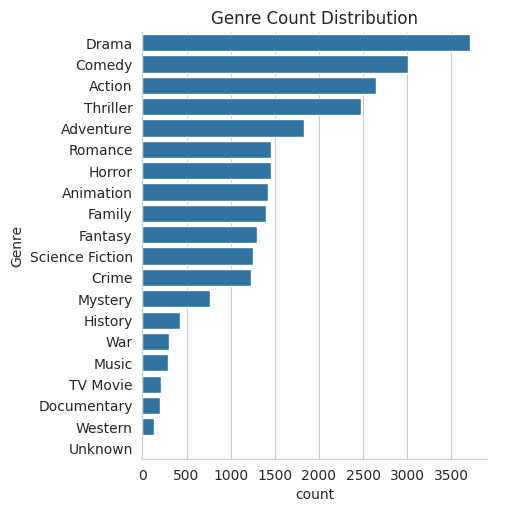

In [99]:
# Visiulize that the Which Genre has most included in all movies:
sns.catplot(y= 'Genre', data= df, kind= 'count' , order= df['Genre'].value_counts().index)
plt.title("Genre Count Distribution")
plt.show()

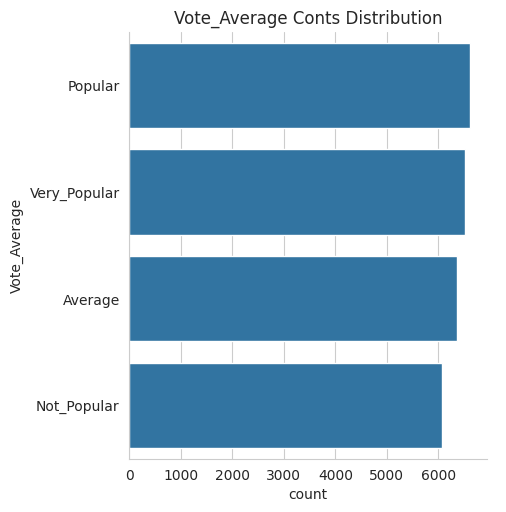

In [100]:
# Visiulize the Vote_average of Every movie that have more Votes
sns.catplot(y= 'Vote_Average', data= df, kind= 'count' , order= df['Vote_Average'].value_counts().index)
plt.title("Vote_Average Conts Distribution")
plt.show()

In [102]:
# Check the ost popular Movies with large populairty
df[df['Popularity'] == df['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Very_Popular,Science Fiction


In [107]:
# Which movies have minmium number of populairty
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
3099,0,61.328,7.1,1392,Average,Unknown


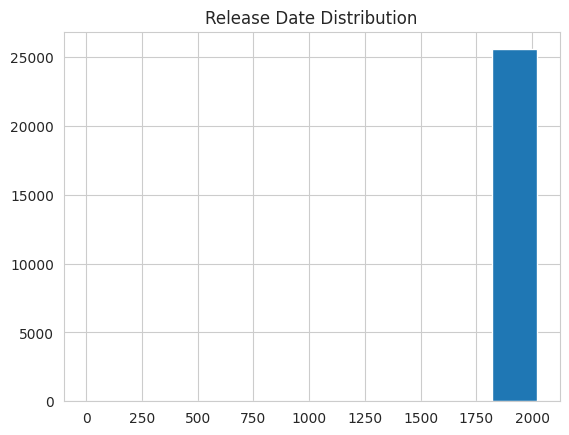

In [113]:
#  In Which year Most movies has been made:
df['Release_Date'].hist()
plt.title('Release Date Distribution')
plt.show()